# CNN Experiment 1 — Fashion-MNIST

This notebook trains a manually designed convolutional neural network to classify ten types of clothing from 28×28 grayscale images.

## 1. Imports and Reproducibility

In [1]:
import os
import random
import warnings

os.environ.setdefault("KERAS_HOME", os.path.abspath(".keras"))
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".mplconfig"))

import numpy as np
import tensorflow as tf

SEED = 42
FAST_RUN = os.getenv("ASSIGNMENT_FAST_RUN", "0") == "1"
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

warnings.filterwarnings("ignore")
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))
print("Fast validation mode:", FAST_RUN)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, GlobalAveragePooling2D, Input, MaxPooling2D

sns.set_theme(style="whitegrid")

TensorFlow version: 2.20.0
Available GPU devices: []
Fast validation mode: True


## 2. Load and Explore Fashion-MNIST

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
if FAST_RUN:
    X_train_full, _, y_train_full, _ = train_test_split(
        X_train_full, y_train_full, train_size=12000, stratify=y_train_full, random_state=SEED
    )
    X_test, y_test = X_test[:3000], y_test[:3000]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Pixel range:", X_train_full.min(), "to", X_train_full.max())
print("Classes:", class_names)

Training images: (12000, 28, 28)
Training labels: (12000,)
Test images: (3000, 28, 28)
Pixel range: 0 to 255
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


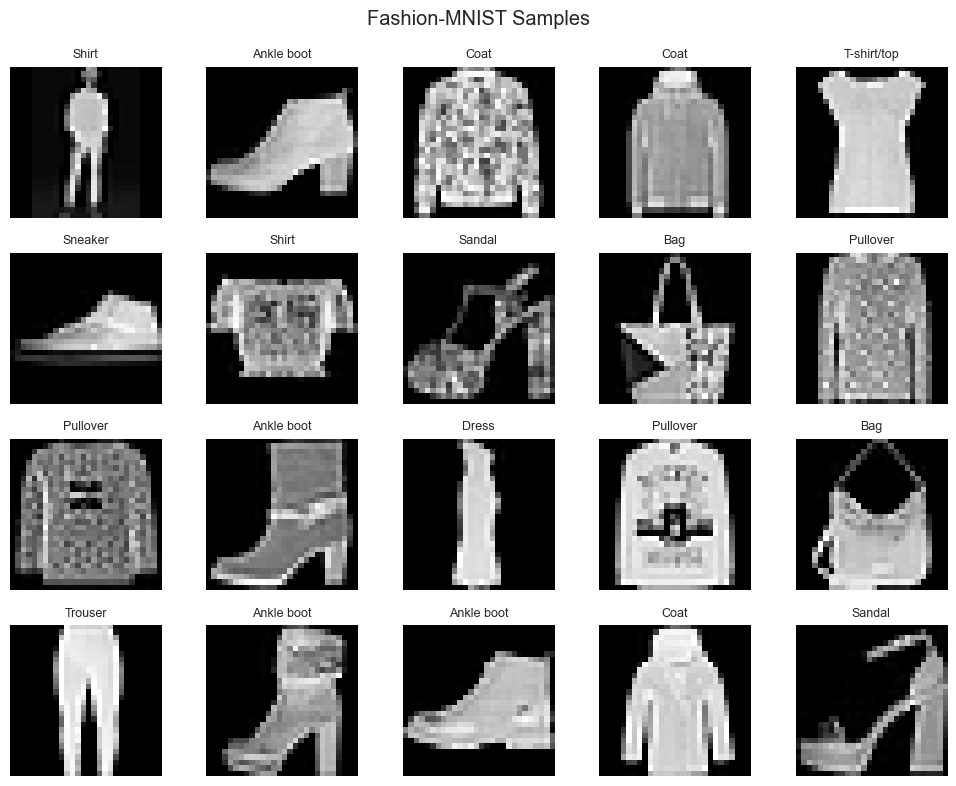

In [3]:
plt.figure(figsize=(10, 8))
for index in range(20):
    plt.subplot(4, 5, index + 1)
    plt.imshow(X_train_full[index], cmap="gray")
    plt.title(class_names[y_train_full[index]], fontsize=9)
    plt.axis("off")
plt.suptitle("Fashion-MNIST Samples")
plt.tight_layout()
plt.show()

## 3. Normalize and Prepare Train / Validation / Test Data

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=SEED
)
X_train = (X_train.astype("float32") / 255.0)[..., np.newaxis]
X_val = (X_val.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test.astype("float32") / 255.0)[..., np.newaxis]
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (9600, 28, 28, 1) Validation: (2400, 28, 28, 1) Test: (3000, 28, 28, 1)


## 4. Build the CNN

Convolution layers learn local visual patterns, max pooling reduces spatial size, batch normalization stabilizes training, and dropout reduces overfitting. Global average pooling converts the final feature maps to a compact vector before the softmax classifier.

In [5]:
tf.keras.backend.clear_session()
fashion_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, 3, padding="same", activation="relu"),
    BatchNormalization(momentum=0.9),
    MaxPooling2D(),
    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(momentum=0.9),
    MaxPooling2D(),
    Conv2D(96, 3, padding="same", activation="relu"),
    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(10, activation="softmax"),
], name="fashion_mnist_cnn")
fashion_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
fashion_model.summary()

Model: "fashion_mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 96)       │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,450 (318.16 KB)

 Trainable params: 81,258 (317.41 KB)

 Non-trainable params: 192 (768.00 B)

## 5. Train Model

In [6]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]
history = fashion_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=5 if FAST_RUN else 10, batch_size=128, callbacks=callbacks, verbose=2
)

Epoch 1/5


75/75 - 6s - 83ms/step - accuracy: 0.5616 - loss: 1.2228 - val_accuracy: 0.7625 - val_loss: 0.7610 - learning_rate: 1.0000e-03


Epoch 2/5


75/75 - 4s - 57ms/step - accuracy: 0.7426 - loss: 0.7054 - val_accuracy: 0.8092 - val_loss: 0.5623 - learning_rate: 1.0000e-03


Epoch 3/5


75/75 - 4s - 53ms/step - accuracy: 0.7966 - loss: 0.5627 - val_accuracy: 0.8192 - val_loss: 0.5044 - learning_rate: 1.0000e-03


Epoch 4/5


75/75 - 4s - 58ms/step - accuracy: 0.8214 - loss: 0.4931 - val_accuracy: 0.8500 - val_loss: 0.4351 - learning_rate: 1.0000e-03


Epoch 5/5


75/75 - 4s - 57ms/step - accuracy: 0.8420 - loss: 0.4431 - val_accuracy: 0.7967 - val_loss: 0.5485 - learning_rate: 1.0000e-03


## 6. Accuracy and Loss Graphs

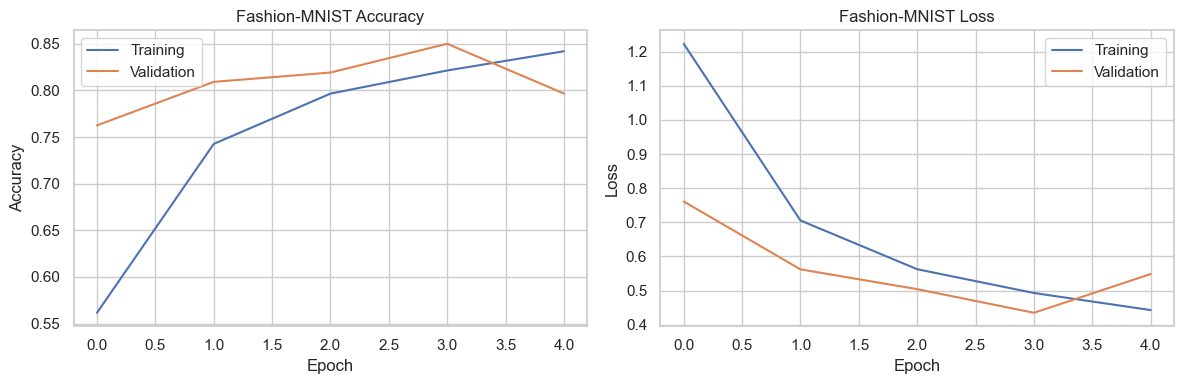

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set(title="Fashion-MNIST Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[0].legend()
axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set(title="Fashion-MNIST Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Test Evaluation

In [8]:
test_loss, test_accuracy = fashion_model.evaluate(X_test, y_test, verbose=0)
probabilities = fashion_model.predict(X_test, verbose=0)
y_pred = probabilities.argmax(axis=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names))

Test loss: 0.4402
Test accuracy: 0.8440
              precision    recall  f1-score   support

 T-shirt/top       0.78      0.82      0.80       302
     Trouser       0.99      0.95      0.97       308
    Pullover       0.75      0.83      0.79       310
       Dress       0.82      0.83      0.82       298
        Coat       0.78      0.66      0.72       324
      Sandal       0.91      0.98      0.94       285
       Shirt       0.56      0.59      0.58       298
     Sneaker       0.95      0.90      0.92       293
         Bag       0.98      0.96      0.97       297
  Ankle boot       0.95      0.96      0.96       285

    accuracy                           0.84      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.84      0.84      3000



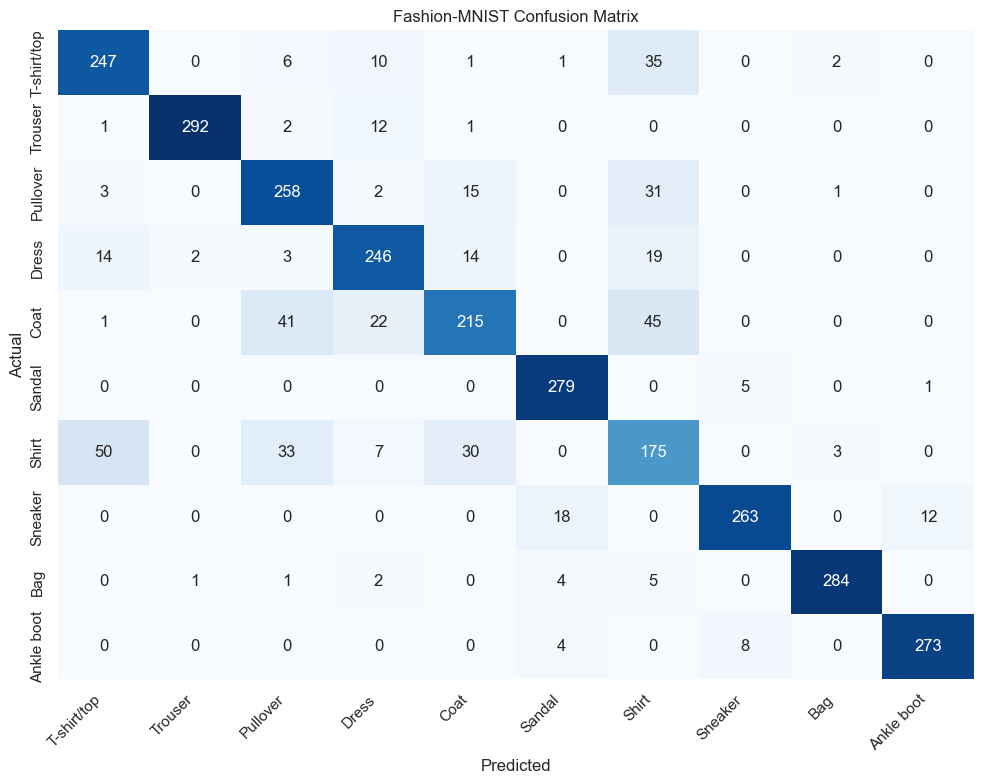

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title("Fashion-MNIST Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 8. Sample Predictions

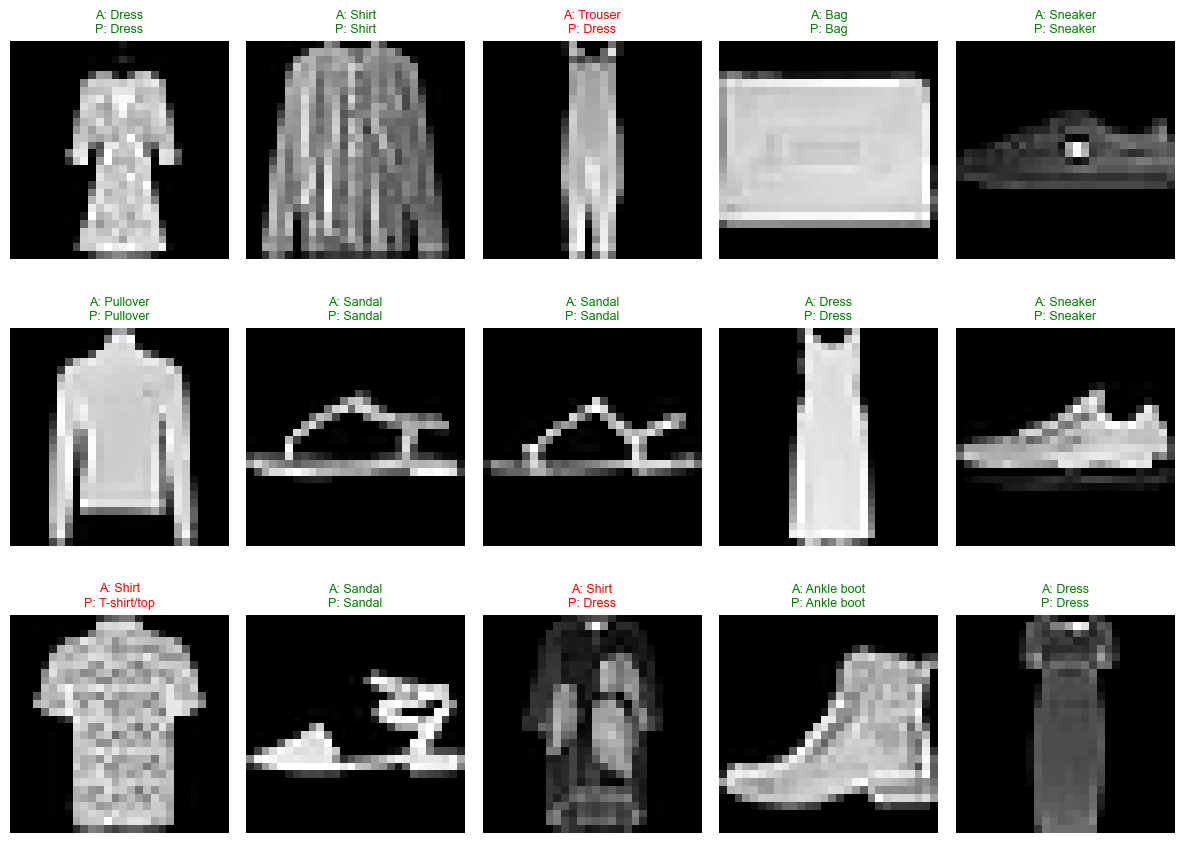

In [10]:
rng = np.random.default_rng(SEED)
indices = rng.choice(len(X_test), size=15, replace=False)
plt.figure(figsize=(12, 9))
for plot_index, image_index in enumerate(indices):
    plt.subplot(3, 5, plot_index + 1)
    plt.imshow(X_test[image_index].squeeze(), cmap="gray")
    color = "green" if y_pred[image_index] == y_test[image_index] else "red"
    plt.title(f"A: {class_names[y_test[image_index]]}\nP: {class_names[y_pred[image_index]]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

## 9. Conclusion

The CNN learns spatial clothing features that a plain fully connected model cannot use directly. The test accuracy, per-class report, and confusion matrix above show both overall performance and the clothing categories that are most often confused.